# Compare mosaics

To fill the internal gap in the F200 and F090 images that is saturated we used the IFU data to construct equialent F200 images for the central region. 

But when coadding the IFU data to the F200W image I used the reproject interp algorithm, which is not flux preserving and want to compare how it differs between the two.

In [2]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table


In [3]:
interp_image = fits.open("/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/IFU/photometry/f200w_ifu_coadd_masked.fits")

In [4]:
exact_image = fits.open("/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/IFU/photometry/f200w_ifu_coadd_masked_exact.fits")

In [7]:
res = {'x_cen': 7537.219884279368, 'y_cen': 7332.548985227105, 'cutout_origin': (7438, 7233), 'cutout_shape': (201, 201), 'success': True, 'fun': 634828122.6442474}
elip_par = {'pixels_used': 3201601, 'peak_yx': (7332, 7538), 'mean_yx': (7364.017702693088, 7532.88931445317), 'theta_deg': -0.7818587242987439, 'astro_pa_deg': 90.78185872429874, 'q': 0.2939043540079123, 'eps': 0.7060956459920877, 'sigma_major_pix': 737.4714742203379, 'sigma_minor_pix': 216.7460772299912, 'major_axis_pix': 2949.8858968813515, 'inclination_deg': 72.90815072586739, 'cutout_origin': (5537, 5333), 'cutout_shape': (4001, 4001), 'sky': 2.9966928958892822}

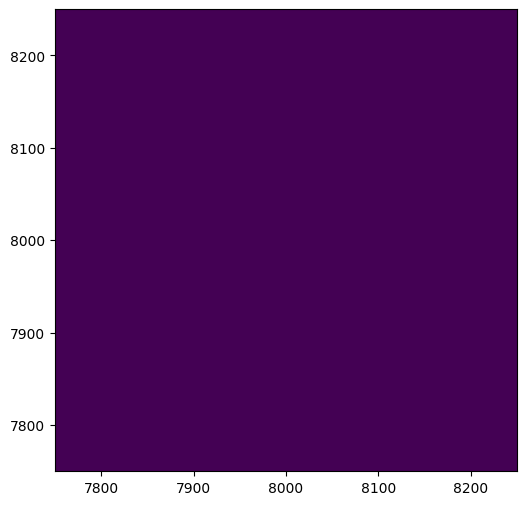

In [6]:
# make a ratio image
ratio = exact_image[0].data / interp_image[0].data

# plot the ratio image
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(
    ratio,
    origin="lower",
    vmin=np.nanpercentile(ratio, 5),
    vmax=np.nanpercentile(ratio, 95),
)
ax.set_xlim(7750, 8250)
ax.set_ylim(7750, 8250)
plt.show()

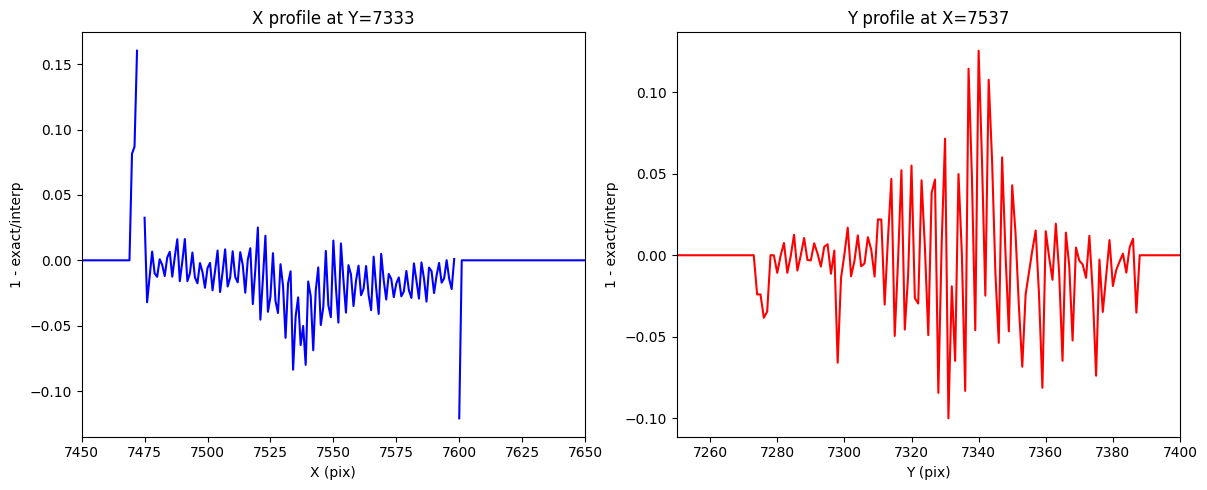

In [22]:
# plot the hisogram of the ratio image in the central region in XY
# plot count histogram in the X direction at the Y center and the Y direction at the X center
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
yc, xc = res["y_cen"], res["x_cen"]
y_center = int(round(yc))
x_center = int(round(xc))
ax[0].plot(1 - ratio[y_center, :], color='blue')
ax[0].set_title(f"X profile at Y={y_center}")
ax[0].set_xlabel("X (pix)")
ax[0].set_ylabel("1 - exact/interp")
ax[1].plot(1-ratio[:, x_center], color='red')
ax[1].set_title(f"Y profile at X={x_center}")
ax[1].set_xlabel("Y (pix)")
ax[1].set_ylabel("1 - exact/interp")

# add vertical lines at the center and at the edges of the zoomed region

# ax[0].axvline(x=xc, color='black', linestyle='-')

# ax[1].axvline(x=yc, color='black', linestyle='-')
plt.tight_layout()
#fig.savefig(os.path.join(checkplot_dir, f"{prefix}_02_profiles.png"), dpi=dpi)
#plt.close(fig)#
ax[0].set_xlim(7450, 7650)
ax[1].set_xlim(7250, 7400)

plt.show()

In [43]:
# compute the median absolute deviation between the two in the central region
center_region_exact = exact_image[0].data[7250:7400, 7450:7650]
center_region_interp = interp_image[0].data[7250:7400, 7450:7650]

mad = np.nanmean(np.abs(center_region_exact - center_region_interp))/np.nanmean(center_region_exact)
print(f"Median absolute deviation: {mad}")

Median absolute deviation: 0.011326970532536507


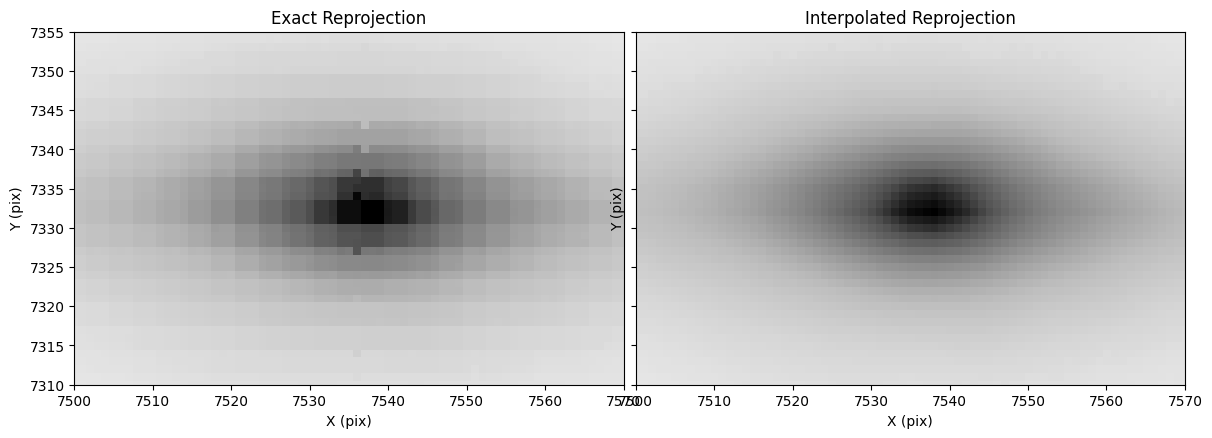

In [28]:
# plot exact and interp images
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
im0 = ax[0].imshow(
    exact_image[0].data,
    origin="lower",
    vmin=np.nanmin(exact_image[0].data),
    vmax=np.nanmax(exact_image[0].data),
    cmap='Greys'
)
ax[0].set_title("Exact Reprojection")
ax[0].set_xlabel("X (pix)")
ax[0].set_ylabel("Y (pix)")
im1 = ax[1].imshow(
    interp_image[0].data,
    origin="lower",
    vmin=np.nanmin(interp_image[0].data),
    vmax=np.nanmax(interp_image[0].data),
    cmap='Greys'
)
ax[1].set_title("Interpolated Reprojection")
ax[1].set_xlabel("X (pix)")
ax[1].set_ylabel("Y (pix)")
plt.tight_layout()
# zoom into the central region
zoom_region_x = (7500, 7570)
zoom_region_y = (7310, 7355)
ax[0].set_xlim(*zoom_region_x)
ax[0].set_ylim(*zoom_region_y)
ax[1].set_xlim(*zoom_region_x)
ax[1].set_ylim(*zoom_region_y)
plt.show()